# Credit Default Risk — Predictive Modelling
### Logistic Regression · Random Forest · XGBoost

**Dataset:** UCI Default of Credit Card Clients (Taiwan, 2005)  
**Observations:** 30,000 | **Target:** default.payment.next.month (binary)

---
#### Pipeline Overview
1. Data Loading, Cleaning & Feature Engineering  
2. Train / Test Split + Class Imbalance Handling (SMOTE)  
3. Model Training — Logistic Regression, Random Forest, XGBoost  
4. Threshold Tuning (Youden-J / F1-optimal)  
5. ROC & Precision–Recall Curves  
6. Confusion Matrices & Classification Reports  
7. KS Statistic, Lift & Cumulative Gains  
8. Probability Calibration  
9. Feature Importance Comparison  
10. 5-Fold Cross-Validation  
11. Final Model Scorecard  
12. Save Models


## 1. Setup & Libraries

In [1]:
# Install required packages (run once)
# !pip install xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, confusion_matrix,
    classification_report, brier_score_loss, f1_score
)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from scipy.stats import rankdata
import joblib

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
COLORS = {'lr': '#2563EB', 'rf': '#16A34A', 'xgb': '#DC2626', 'neutral': '#6B7280'}
LABELS = {'lr': 'Logistic Regression', 'rf': 'Random Forest', 'xgb': 'XGBoost'}


## 2. Data Loading, Cleaning & Feature Engineering

All preprocessing is consolidated here so every model trains on identical features.


In [4]:
df = pd.read_csv('UCI_Credit_Card.csv')   # adjust path if needed

# ── Drop ID, rename target ────────────────────────────────────────────────────
df.drop(columns=['ID'], inplace=True)
df.rename(columns={'default.payment.next.month': 'DEFAULT'}, inplace=True)

# ── Fix undocumented category codes ──────────────────────────────────────────
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)   # collapse to 'other'
df['MARRIAGE']  = df['MARRIAGE'].replace(0, 3)             # collapse to 'other'

print(f"Shape: {df.shape}")
print(f"Default rate: {df['DEFAULT'].mean():.3%}  ({df['DEFAULT'].sum():,} / {len(df):,})")


Shape: (30000, 24)
Default rate: 22.120%  (6,636 / 30,000)


In [5]:
# ══ Feature Engineering ════════════════════════════════════════════════════

bill_cols  = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols   = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
repay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

# 1. Average monthly bill & payment
df['AVG_BILL']    = df[bill_cols].mean(axis=1)
df['AVG_PAY_AMT'] = df[pay_cols].mean(axis=1)

# 2. Credit utilisation ratio (clipped at 1)
df['UTIL_RATIO'] = (df['AVG_BILL'] / df['LIMIT_BAL'].replace(0, np.nan)).clip(upper=1).fillna(0)

# 3. Maximum repayment delay over 6 months
df['MAX_DELAY'] = df[repay_cols].max(axis=1)

# 4. Count of months with any payment delay
df['N_DELAY'] = (df[repay_cols] > 0).sum(axis=1)

# 5. Payment-to-bill ratio (how much of total bill was paid)
total_bill = df[bill_cols].sum(axis=1).replace(0, np.nan)
df['PAY_BILL_RATIO'] = (df[pay_cols].sum(axis=1) / total_bill).clip(upper=5).fillna(0)

# ── One-hot encode categoricals ───────────────────────────────────────────────
df = pd.get_dummies(df, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

# ── Drop raw bill/pay columns ─────────────────────────────────────────────────
df.drop(columns=bill_cols + pay_cols, inplace=True)

print(f"Features after engineering: {df.shape[1]-1}")
print("Columns:", df.columns.tolist())


Features after engineering: 20
Columns: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'DEFAULT', 'AVG_BILL', 'AVG_PAY_AMT', 'UTIL_RATIO', 'MAX_DELAY', 'N_DELAY', 'PAY_BILL_RATIO', 'SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


## 3. Train / Test Split & Class Imbalance

The dataset is imbalanced (~22% defaults). We apply **SMOTE only on the training set**  
to avoid data leakage — the test set always reflects the real-world class distribution.


In [6]:
X = df.drop(columns=['DEFAULT'])
y = df['DEFAULT']
feature_names = X.columns.tolist()

# ── 80/20 stratified split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train default rate: {y_train.mean():.3%}  |  Test default rate: {y_test.mean():.3%}")


Train: 24,000  |  Test: 6,000
Train default rate: 22.121%  |  Test default rate: 22.117%


In [7]:
# ── Scale (Logistic Regression needs this; trees don't) ──────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── SMOTE on training set only ────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f"After SMOTE — Train size: {len(X_train_sm):,}")
print(f"Class balance: {pd.Series(y_train_sm).value_counts().to_dict()}")


After SMOTE — Train size: 37,382
Class balance: {0: 18691, 1: 18691}


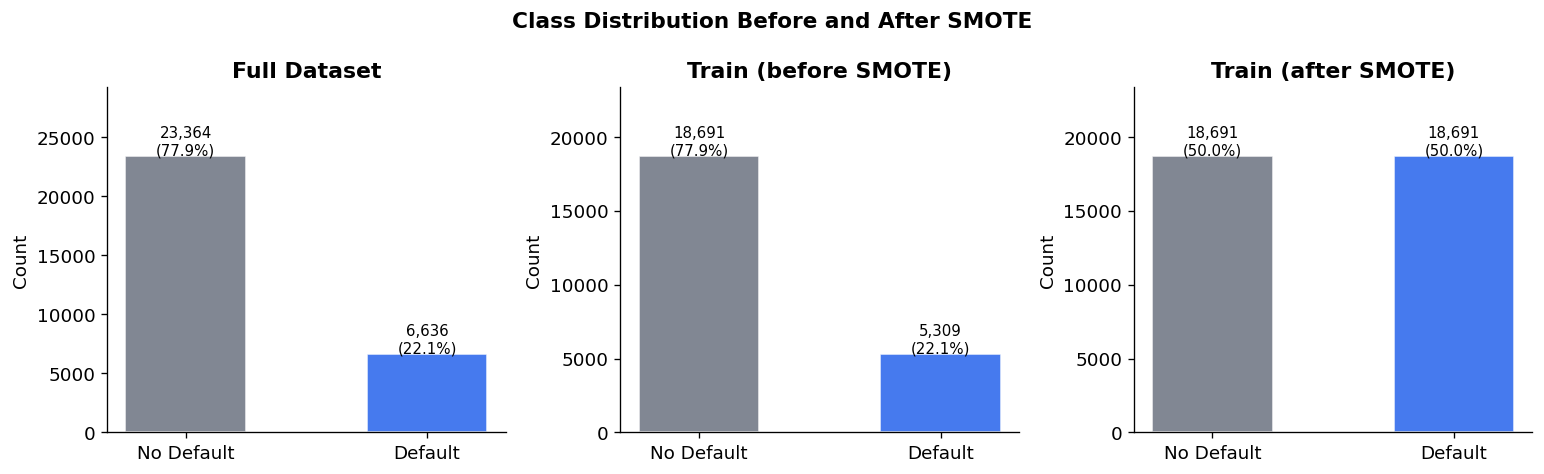

In [8]:
# ── Class distribution panel ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, counts, title in zip(
    axes,
    [y.value_counts(), y_train.value_counts(), pd.Series(y_train_sm).value_counts()],
    ['Full Dataset', 'Train (before SMOTE)', 'Train (after SMOTE)']
):
    counts = counts.sort_index()
    bars = ax.bar(['No Default', 'Default'], counts.values,
                  color=[COLORS['neutral'], COLORS['lr']], alpha=0.85,
                  edgecolor='white', width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}\n({val/counts.sum():.1%})', ha='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, counts.max() * 1.25)
    ax.set_ylabel('Count')

plt.suptitle('Class Distribution Before and After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Model Training

Tree-based models use **unscaled** features directly (scaling is irrelevant to splits).  
Logistic Regression uses the **SMOTE-balanced scaled** training set.  
Hyperparameters are well-tested defaults for credit scoring — Optuna / GridSearchCV  
tuning can be added as a next step.


In [9]:
# ── 4.1 Logistic Regression ──────────────────────────────────────────────────
lr = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
print("Logistic Regression — trained")


Logistic Regression — trained


In [10]:
# ── 4.2 Random Forest ────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    class_weight='balanced_subsample', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest — trained")


Random Forest — trained


In [11]:
# ── 4.3 XGBoost ──────────────────────────────────────────────────────────────
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
print(f"XGBoost — trained  (scale_pos_weight = {scale_pos})")


XGBoost — trained  (scale_pos_weight = 3)


## 5. Predictions & Optimal Threshold Selection

The default 0.5 cut-off is rarely optimal on imbalanced credit data.  
We compute both the **Youden-J threshold** (maximises TPR − FPR) and the  
**F1-optimal threshold** for each model and use Youden-J for evaluation.


In [12]:
def find_thresholds(y_true, probs_arr):
    fpr, tpr, thr_roc = roc_curve(y_true, probs_arr)
    youden_thr = float(thr_roc[np.argmax(tpr - fpr)])

    prec, rec, thr_pr = precision_recall_curve(y_true, probs_arr)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    f1_thr = float(thr_pr[np.argmax(f1s[:-1])])

    return round(youden_thr, 4), round(f1_thr, 4)

# Predicted probabilities on test set
probs = {
    'lr':  lr.predict_proba(X_test_sc)[:, 1],
    'rf':  rf.predict_proba(X_test)[:, 1],
    'xgb': xgb.predict_proba(X_test)[:, 1]
}

thresholds = {}
for key, prob in probs.items():
    yj, f1t = find_thresholds(y_test, prob)
    thresholds[key] = {'youden': yj, 'f1': f1t}
    print(f"{LABELS[key]:25s}  Youden-J: {yj:.4f}  |  F1-optimal: {f1t:.4f}")


Logistic Regression        Youden-J: 0.5688  |  F1-optimal: 0.5963
Random Forest              Youden-J: 0.5223  |  F1-optimal: 0.5808
XGBoost                    Youden-J: 0.4546  |  F1-optimal: 0.5154


## 6. ROC Curves & Precision–Recall Curves

**ROC AUC** — overall discrimination power, threshold-free.  
**Average Precision (PR AUC)** — preferred metric under class imbalance;  
it directly measures how well the model ranks defaults above non-defaults  
without inflating results due to the large negative class.


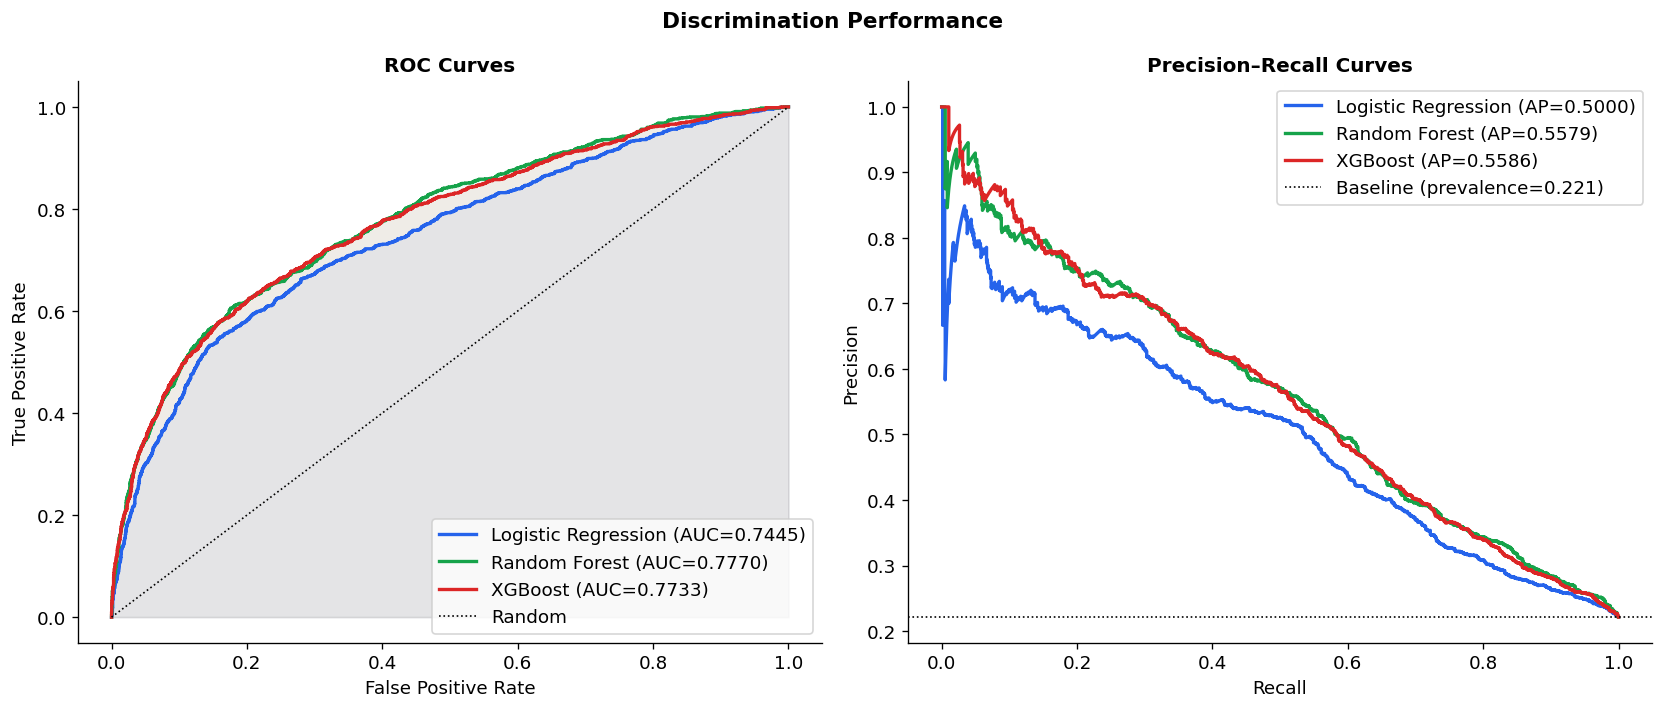

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for key in ['lr', 'rf', 'xgb']:
    prob  = probs[key]
    color = COLORS[key]
    label = LABELS[key]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.4f})')
    axes[0].fill_between(fpr, tpr, alpha=0.06, color=color)

    # PR
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{label} (AP={ap:.4f})')

axes[0].plot([0,1],[0,1],'k:',lw=1,label='Random')
axes[0].set_title('ROC Curves', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

axes[1].axhline(y_test.mean(), color='k', linestyle=':', lw=1,
                label=f'Baseline (prevalence={y_test.mean():.3f})')
axes[1].set_title('Precision–Recall Curves', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

plt.suptitle('Discrimination Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Confusion Matrices & Classification Reports

Using **Youden-J threshold** — balances sensitivity (catching defaults) and  
specificity (avoiding false alarms), appropriate for credit risk applications.


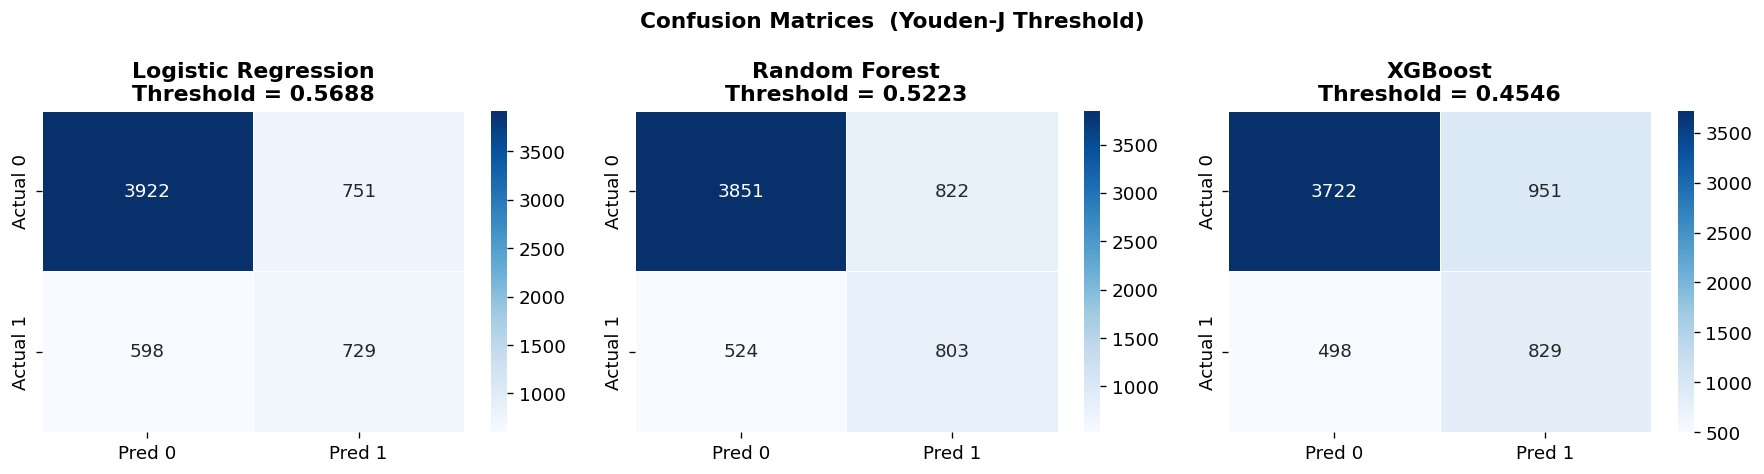

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key in zip(axes, ['lr', 'rf', 'xgb']):
    thr   = thresholds[key]['youden']
    preds = (probs[key] >= thr).astype(int)
    cm    = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                linewidths=0.5, linecolor='white')
    ax.set_title(f'{LABELS[key]}\nThreshold = {thr}', fontweight='bold')

plt.suptitle('Confusion Matrices  (Youden-J Threshold)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
for key in ['lr', 'rf', 'xgb']:
    thr   = thresholds[key]['youden']
    preds = (probs[key] >= thr).astype(int)
    print(f"{'─'*56}")
    print(f"  {LABELS[key]}   (threshold = {thr})")
    print(f"{'─'*56}")
    print(classification_report(y_test, preds, target_names=['No Default', 'Default']))


────────────────────────────────────────────────────────
  Logistic Regression   (threshold = 0.5688)
────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  No Default       0.87      0.84      0.85      4673
     Default       0.49      0.55      0.52      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.69      0.69      6000
weighted avg       0.78      0.78      0.78      6000

────────────────────────────────────────────────────────
  Random Forest   (threshold = 0.5223)
────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  No Default       0.88      0.82      0.85      4673
     Default       0.49      0.61      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000

──────────────────────────────────

## 8. KS Statistic, Lift & Cumulative Gains

**KS Statistic** — maximum gap between Default and Non-Default CDFs.  
Industry benchmark for retail credit: KS > 0.40 = good, > 0.50 = strong.

**Cumulative Lift** — how many times better than random when targeting the top X%.  
**Gains Chart** — what % of all defaults are captured when contacting the top X% of clients.


In [16]:
def compute_ks(probs_arr, actuals):
    df_ks = pd.DataFrame({'prob': probs_arr, 'actual': actuals.values})
    df_ks = df_ks.sort_values('prob', ascending=False).reset_index(drop=True)
    df_ks['cum_def']    = np.cumsum(df_ks['actual'])     / df_ks['actual'].sum()
    df_ks['cum_nondef'] = np.cumsum(1-df_ks['actual'])   / (1-df_ks['actual']).sum()
    df_ks['ks']         = df_ks['cum_def'] - df_ks['cum_nondef']
    return df_ks['ks'].max(), df_ks['ks'].idxmax(), df_ks

for key in ['lr', 'rf', 'xgb']:
    ks, _, _ = compute_ks(probs[key], y_test)
    print(f"{LABELS[key]:25s}  KS = {ks:.4f}")


Logistic Regression        KS = 0.3886
Random Forest              KS = 0.4300
XGBoost                    KS = 0.4220


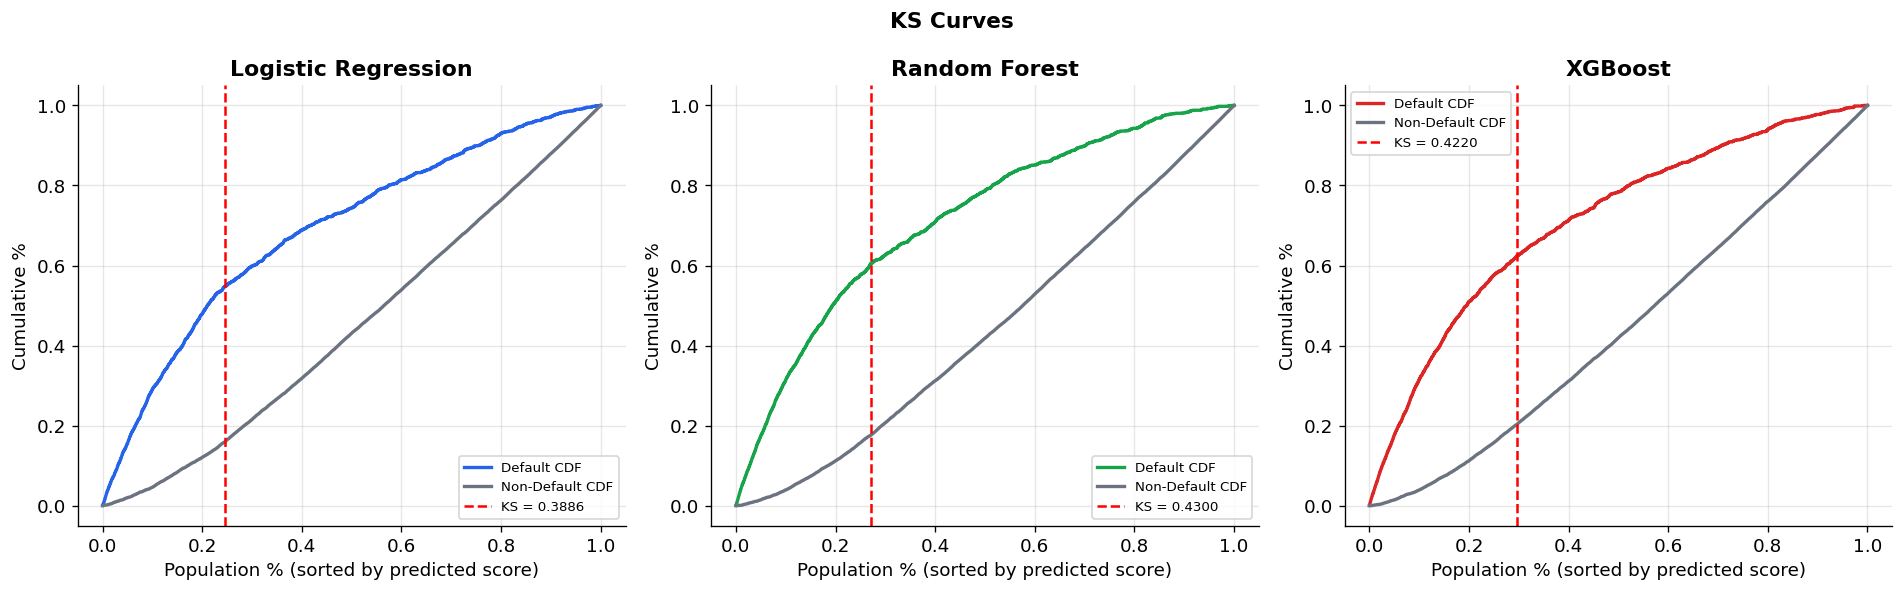

In [17]:
# ── KS Curves ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, key in zip(axes, ['lr', 'rf', 'xgb']):
    ks_val, ks_idx, df_ks = compute_ks(probs[key], y_test)
    x = np.arange(1, len(df_ks)+1) / len(df_ks)
    ax.plot(x, df_ks['cum_def'],    color=COLORS[key],      lw=2, label='Default CDF')
    ax.plot(x, df_ks['cum_nondef'], color=COLORS['neutral'], lw=2, label='Non-Default CDF')
    ax.axvline(ks_idx/len(df_ks), color='red', linestyle='--',
               label=f'KS = {ks_val:.4f}')
    ax.set_title(LABELS[key], fontweight='bold')
    ax.set_xlabel('Population % (sorted by predicted score)')
    ax.set_ylabel('Cumulative %')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('KS Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ks_curves.png', dpi=150, bbox_inches='tight')
plt.show()


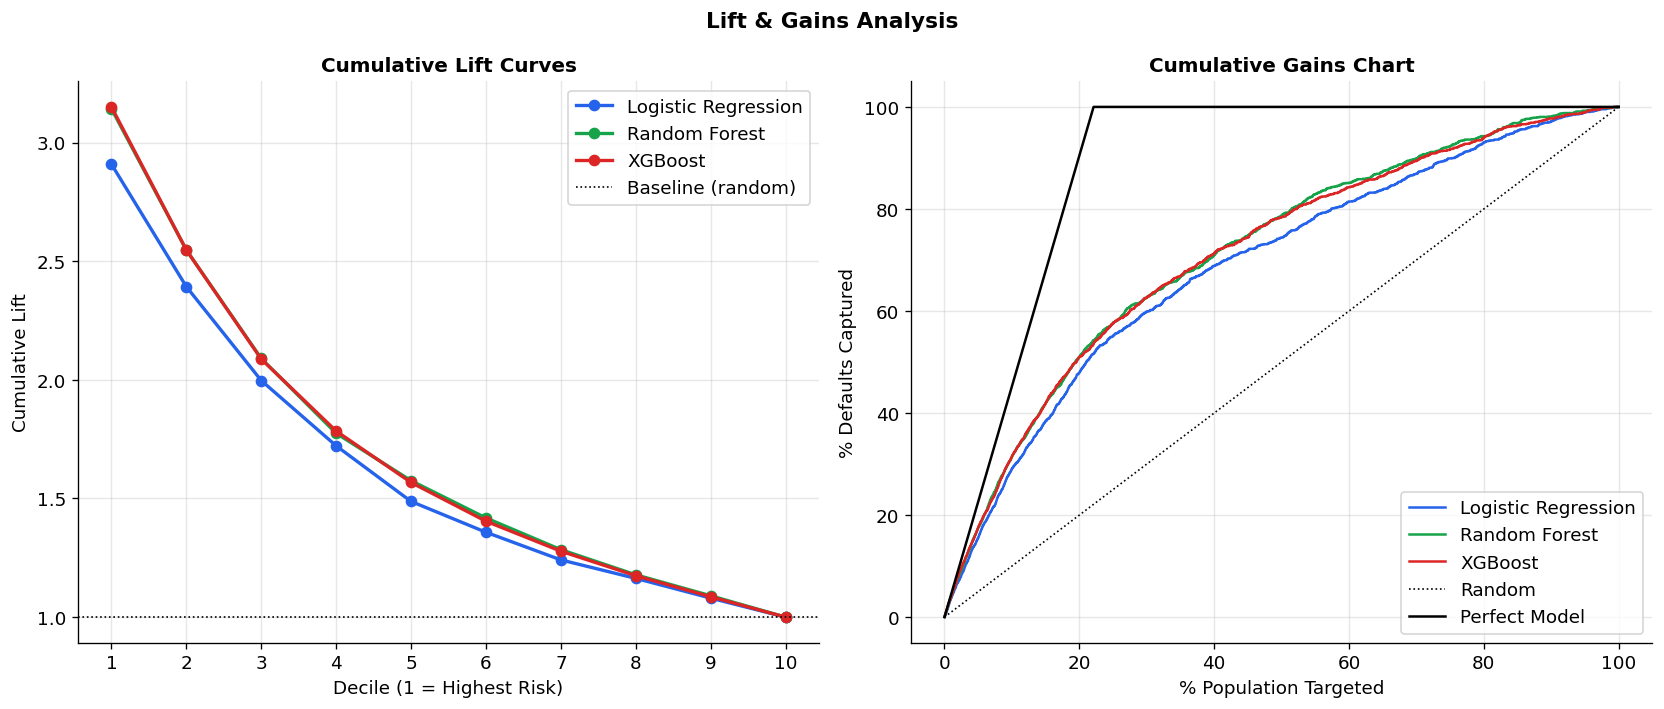

In [18]:
# ── Lift & Gains (all models overlaid) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

baseline_rate = y_test.mean()
n_obs = len(y_test)
n_def = int(y_test.sum())

for key in ['lr', 'rf', 'xgb']:
    ldf = (pd.DataFrame({'prob': probs[key], 'actual': y_test.values})
             .sort_values('prob', ascending=False).reset_index(drop=True))
    ldf['decile'] = pd.qcut(ldf.index, q=10, labels=False)

    ls = ldf.groupby('decile').agg(
        total=('actual', 'count'), defaults=('actual', 'sum')
    ).reset_index()
    ls['cum_defaults'] = ls['defaults'].cumsum()
    ls['cum_total']    = ls['total'].cumsum()
    ls['cum_lift']     = (ls['cum_defaults'] / ls['cum_total']) / baseline_rate

    axes[0].plot(ls['decile']+1, ls['cum_lift'], marker='o', lw=2,
                 color=COLORS[key], label=LABELS[key])

    model_gains = np.cumsum(ldf['actual'].values)
    x_gains = np.arange(1, n_obs+1)
    axes[1].plot(x_gains/n_obs*100, model_gains/n_def*100,
                 lw=1.5, color=COLORS[key], label=LABELS[key])

# Lift cosmetics
axes[0].axhline(1, color='k', linestyle=':', lw=1, label='Baseline (random)')
axes[0].set_title('Cumulative Lift Curves', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Decile (1 = Highest Risk)')
axes[0].set_ylabel('Cumulative Lift')
axes[0].set_xticks(range(1, 11))
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gains cosmetics
axes[1].plot([0,100],[0,100],'k:',lw=1,label='Random')
axes[1].plot([0, n_def/n_obs*100, 100],[0,100,100],'k-',lw=1.5,label='Perfect Model')
axes[1].set_title('Cumulative Gains Chart', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% Population Targeted')
axes[1].set_ylabel('% Defaults Captured')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Lift & Gains Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lift_gains.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Probability Calibration

Good calibration is essential for **risk pricing and expected loss calculation**.  
If the model says P(default) = 0.30, then ~30% of those clients should actually default.  
**Brier Score** = mean squared error of probability predictions (lower is better).


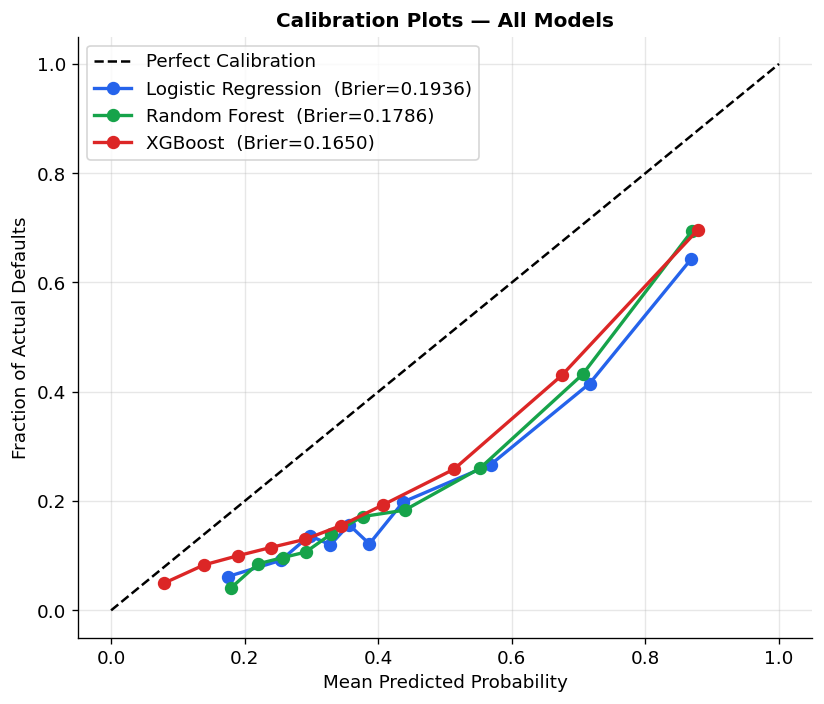

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Perfect Calibration')

for key in ['lr', 'rf', 'xgb']:
    fop, mpv = calibration_curve(y_test, probs[key], n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_test, probs[key])
    ax.plot(mpv, fop, marker='o', color=COLORS[key], lw=2, ms=7,
            label=f'{LABELS[key]}  (Brier={brier:.4f})')

ax.set_title('Calibration Plots — All Models', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Actual Defaults')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Feature Importance

- **Logistic Regression**: absolute standardised coefficients (scaled input → magnitude = importance)  
- **Random Forest**: mean decrease in impurity (Gini importance)  
- **XGBoost**: total gain across all tree splits


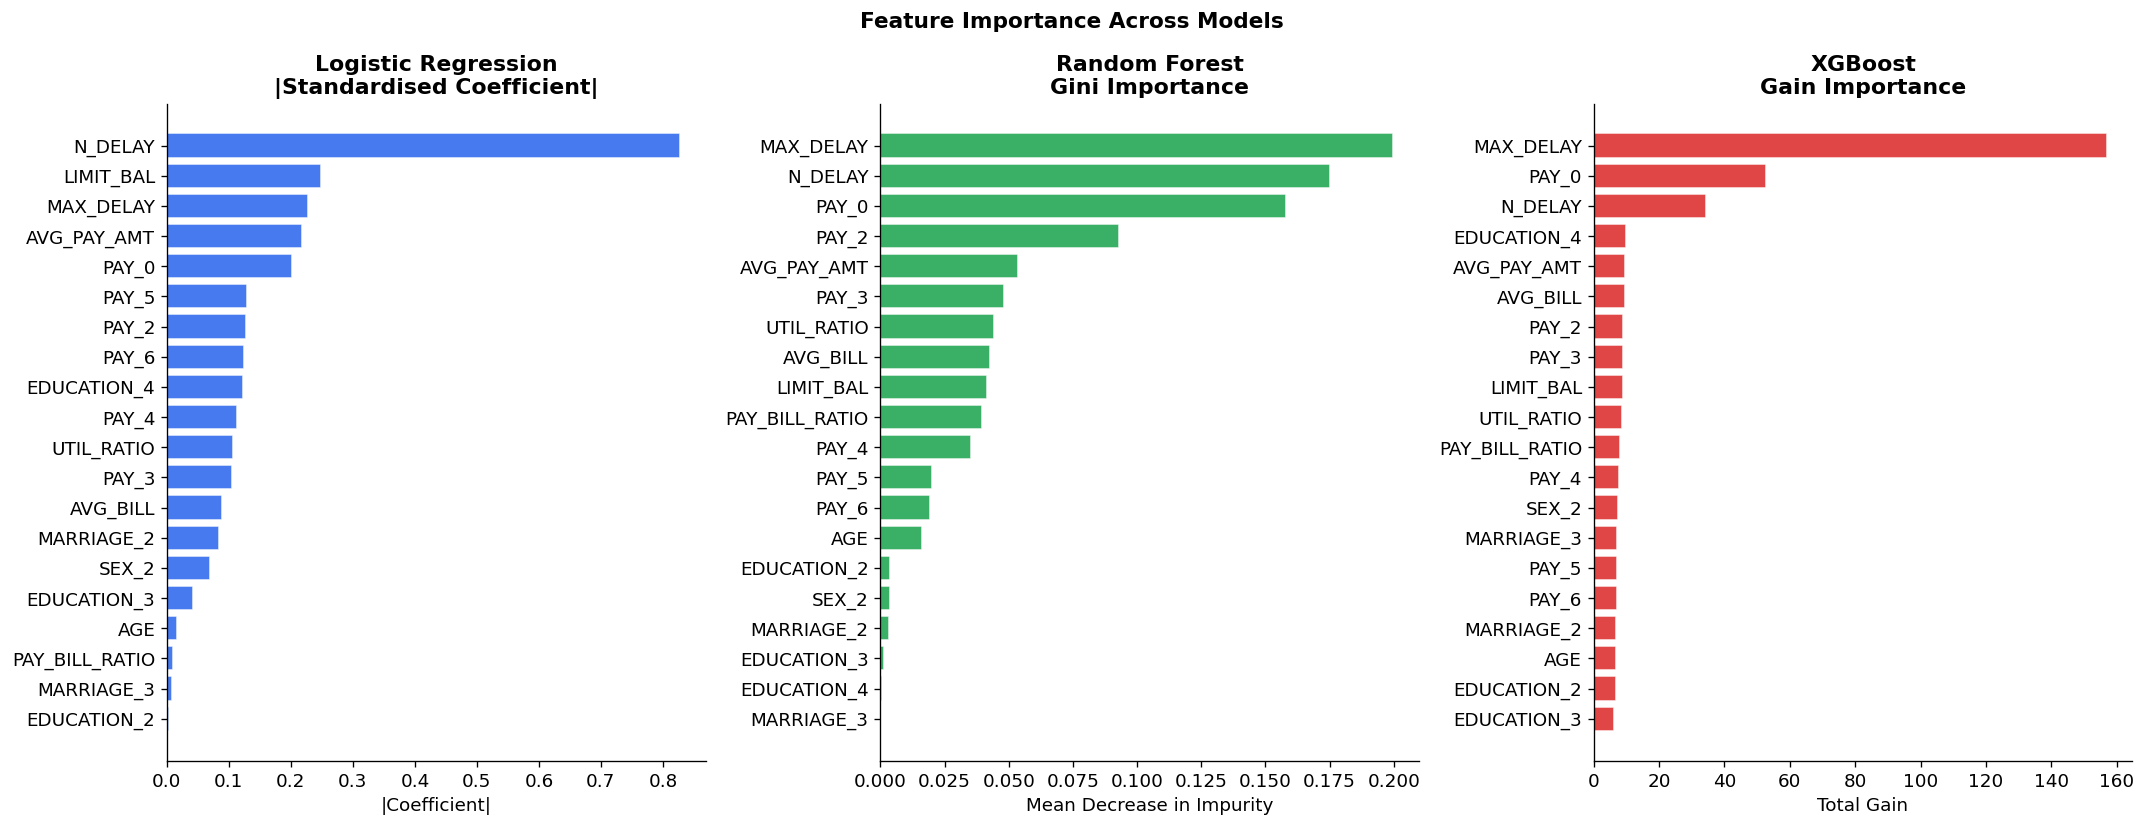

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# LR
lr_imp = pd.Series(np.abs(lr.coef_[0]), index=feature_names).sort_values()
axes[0].barh(lr_imp.index, lr_imp.values, color=COLORS['lr'], alpha=0.85, edgecolor='white')
axes[0].set_title('Logistic Regression\n|Standardised Coefficient|', fontweight='bold')
axes[0].set_xlabel('|Coefficient|')

# RF
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
axes[1].barh(rf_imp.index, rf_imp.values, color=COLORS['rf'], alpha=0.85, edgecolor='white')
axes[1].set_title('Random Forest\nGini Importance', fontweight='bold')
axes[1].set_xlabel('Mean Decrease in Impurity')

# XGB
xgb_scores = pd.Series(
    xgb.get_booster().get_score(importance_type='gain')
).reindex(feature_names, fill_value=0).sort_values()
axes[2].barh(xgb_scores.index, xgb_scores.values, color=COLORS['xgb'], alpha=0.85, edgecolor='white')
axes[2].set_title('XGBoost\nGain Importance', fontweight='bold')
axes[2].set_xlabel('Total Gain')

plt.suptitle('Feature Importance Across Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
# ── Consensus Top Features (average rank across all 3 models) ────────────────
lr_rank  = pd.Series(rankdata(-np.abs(lr.coef_[0])), index=feature_names)
rf_rank  = pd.Series(rankdata(-rf.feature_importances_), index=feature_names)
xgb_raw  = pd.Series(xgb.get_booster().get_score(importance_type='gain')
                     ).reindex(feature_names, fill_value=0)
xgb_rank = pd.Series(rankdata(-xgb_raw.values), index=feature_names)

avg_rank = ((lr_rank + rf_rank + xgb_rank) / 3).sort_values()
print("Top 10 Features by Average Rank Across All Models:")
print(avg_rank.head(10).round(2).to_string())


Top 10 Features by Average Rank Across All Models:
MAX_DELAY       1.67
N_DELAY         2.00
PAY_0           3.33
AVG_PAY_AMT     4.67
PAY_2           6.00
LIMIT_BAL       6.67
PAY_3           8.67
AVG_BILL        9.00
UTIL_RATIO      9.33
EDUCATION_4    10.67


## 11. Stratified 5-Fold Cross-Validation

CV ensures performance is not overly sensitive to a single train/test split.  
Scored on **ROC-AUC** (threshold-free) and **Average Precision** (imbalance-aware).


In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':<25} {'AUC mean':>10} {'AUC std':>9} {'AP mean':>10} {'AP std':>9}")
print('─' * 65)
cv_results = {}
for key, model, Xm, ym in [
    ('lr',  lr,  X_train_sm, y_train_sm),
    ('rf',  rf,  X_train,    y_train),
    ('xgb', xgb, X_train,    y_train)
]:
    auc_cv = cross_val_score(model, Xm, ym, cv=cv, scoring='roc_auc', n_jobs=-1)
    ap_cv  = cross_val_score(model, Xm, ym, cv=cv, scoring='average_precision', n_jobs=-1)
    cv_results[key] = {'AUC': auc_cv, 'AP': ap_cv}
    print(f"{LABELS[key]:<25} {auc_cv.mean():>10.4f} {auc_cv.std():>9.4f} "
          f"{ap_cv.mean():>10.4f} {ap_cv.std():>9.4f}")


Model                       AUC mean   AUC std    AP mean    AP std
─────────────────────────────────────────────────────────────────
Logistic Regression           0.7604    0.0049     0.7638    0.0075
Random Forest                 0.7847    0.0059     0.5593    0.0106
XGBoost                       0.7772    0.0071     0.5550    0.0064


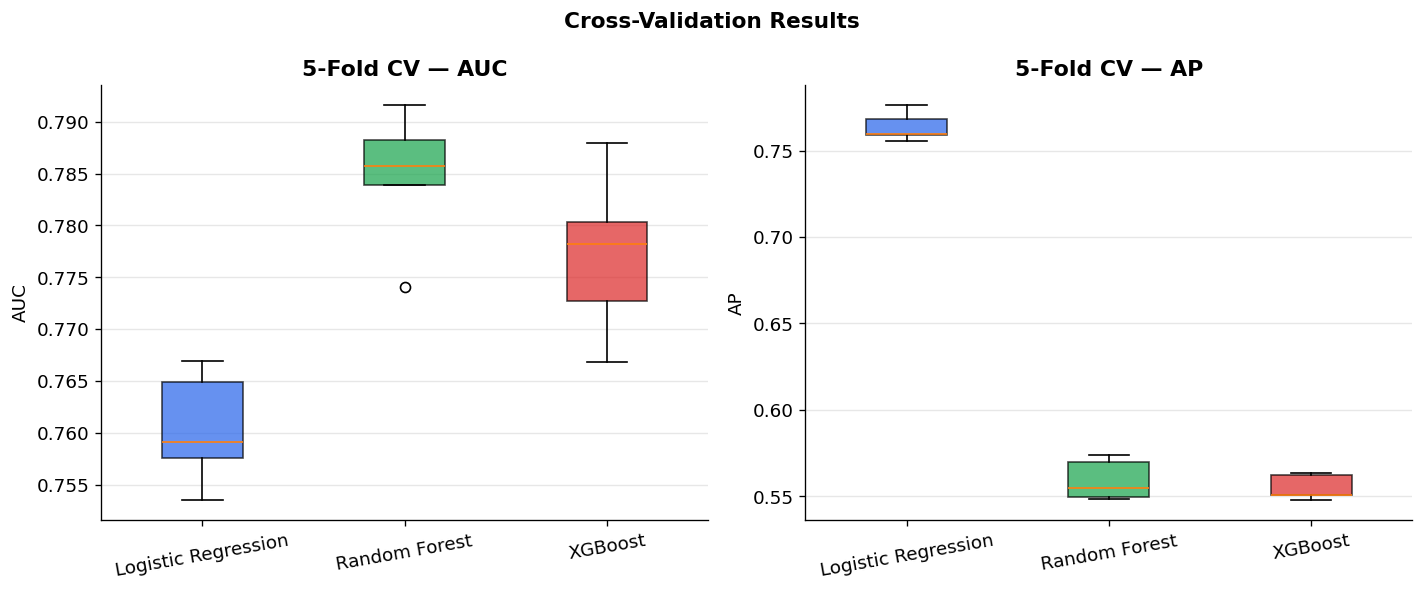

In [23]:
# ── CV Box Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['AUC', 'AP']):
    data  = [cv_results[k][metric] for k in ['lr','rf','xgb']]
    bps   = ax.boxplot(data, patch_artist=True, widths=0.4)
    for patch, key in zip(bps['boxes'], ['lr','rf','xgb']):
        patch.set_facecolor(COLORS[key])
        patch.set_alpha(0.7)
    ax.set_xticks([1,2,3])
    ax.set_xticklabels([LABELS[k] for k in ['lr','rf','xgb']], rotation=10)
    ax.set_title(f'5-Fold CV — {metric}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Validation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Final Model Comparison Scorecard

In [24]:
rows = []
for key in ['lr', 'rf', 'xgb']:
    prob  = probs[key]
    thr_y = thresholds[key]['youden']
    preds = (prob >= thr_y).astype(int)
    ks_val, _, _ = compute_ks(prob, y_test)

    rows.append({
        'Model':              LABELS[key],
        'ROC AUC':            round(roc_auc_score(y_test, prob), 4),
        'Avg Precision':      round(average_precision_score(y_test, prob), 4),
        'Gini':               round(2*roc_auc_score(y_test, prob)-1, 4),
        'KS Statistic':       round(ks_val, 4),
        'Brier Score':        round(brier_score_loss(y_test, prob), 4),
        'F1 (Youden)':        round(f1_score(y_test, preds), 4),
        'Recall (Youden)':    round(preds[y_test==1].mean(), 4),
        'Threshold (Youden)': thr_y,
    })

scorecard = pd.DataFrame(rows).set_index('Model')
print(scorecard.T.to_string())


Model               Logistic Regression  Random Forest  XGBoost
ROC AUC                          0.7445         0.7770   0.7733
Avg Precision                    0.5000         0.5579   0.5586
Gini                             0.4890         0.5539   0.5466
KS Statistic                     0.3886         0.4300   0.4220
Brier Score                      0.1936         0.1786   0.1650
F1 (Youden)                      0.5194         0.5440   0.5336
Recall (Youden)                  0.5494         0.6051   0.6247
Threshold (Youden)               0.5688         0.5223   0.4546


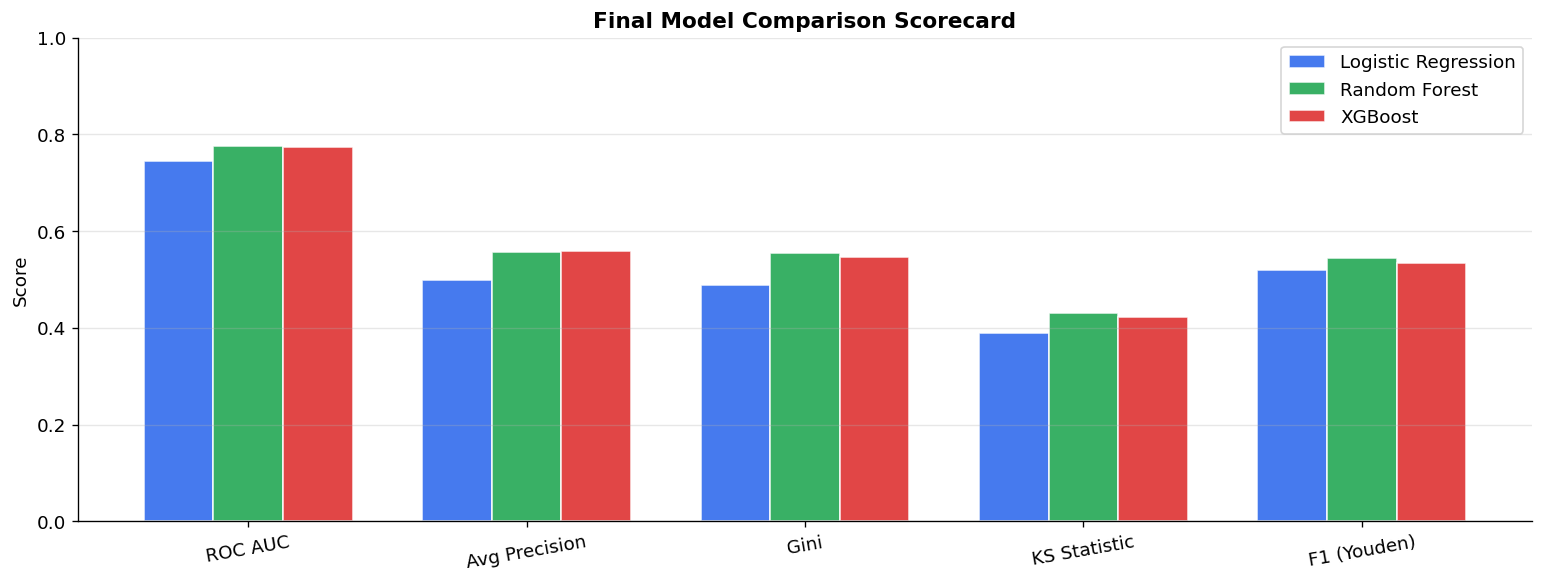

In [25]:
# ── Scorecard bar chart ──────────────────────────────────────────────────────
plot_metrics = ['ROC AUC', 'Avg Precision', 'Gini', 'KS Statistic', 'F1 (Youden)']
x = np.arange(len(plot_metrics))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, key in enumerate(['lr', 'rf', 'xgb']):
    vals = scorecard.loc[LABELS[key], plot_metrics].values.astype(float)
    ax.bar(x + i*w, vals, width=w, label=LABELS[key],
           color=COLORS[key], alpha=0.85, edgecolor='white')

ax.set_xticks(x + w)
ax.set_xticklabels(plot_metrics, rotation=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Final Model Comparison Scorecard', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Save Models & Scaler

Reload with: `model = joblib.load('model_rf.joblib')`


In [26]:
joblib.dump(lr,     'model_lr.joblib')
joblib.dump(rf,     'model_rf.joblib')
joblib.dump(xgb,    'model_xgb.joblib')
joblib.dump(scaler, 'scaler.joblib')
print("Saved: model_lr.joblib | model_rf.joblib | model_xgb.joblib | scaler.joblib")
print()
print("NOTE: Logistic Regression requires scaler.transform(X) before predict_proba().")
print("      Random Forest and XGBoost use raw features directly.")


Saved: model_lr.joblib | model_rf.joblib | model_xgb.joblib | scaler.joblib

NOTE: Logistic Regression requires scaler.transform(X) before predict_proba().
      Random Forest and XGBoost use raw features directly.
